## Multicellular Factor Analysis for spatiotemporal data

---

**NOTE**
This is an advanced user notebook. Familiarity with MOFA-based multicellular factor analysis and spatial single-cell analysis is assumed.

---

In previous tutorials, we focused on expression-derived multicellular programs and spatial data. However, many biological processes—disease progression, tissue development, or treatment response—are inherently temporal. With datasets now including time information, we can study these dynamic processes and improve how data is modeled.

In this tutorial, we extend the mc-ASTRA workflow by adding a temporal covariate as presented in [MEFISTO](https://www.nature.com/articles/s41592-021-01343-9). For each sample, we set the timepoint as a covariate and use Gaussian processes as priors for the factors to learn continuous progression. This yields more precise features and clearer factor-time associations.

This allows the model to jointly capture:

* multicellular gene expression programs
* spatial organization programs
* temporal dynamics

---

### Application to MERFISH colitis progression data

We apply this workflow to MERFISH spatial transcriptomics data reported in [Cadinu et al., Cell 2024](https://www.cell.com/cell/fulltext/S0092-8674(24)00254-X), that profiled the expression of 940 genes in 1.35 million cells imaged across the onset and recovery from a mouse colitis model.

By leveraging both spatial features and temporal covariates, we ask not only whether disease-associated tissue differences are reflected in transcriptional programs, but also, how does the local organization of inflammation-associated fibroblast populations change and how can temporal guidance help interpret the factors?

This tutorial illustrates how MINA can incorporate spatial tissue descriptors and time information into patient maps, providing a flexible framework to compare molecular and structural sources of variation across samples over time. This tutorial should be useful for users trying to extend their models to multiple other tissue features.

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=SyntaxWarning)

import mc_astra as mca
import scanpy as sc
import scanpy.external as sce
import numpy as np
import decoupler as dc
import math
import mofaflex as mf
import mudata as md
import pandas as pd
import matplotlib.pyplot as plt
import squidpy as sq

# packages for font managing
from pathlib import Path
import matplotlib as mpl
from matplotlib import font_manager

/nfs/research/saezrodriguez/rico/MINA_ms/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



#### Importing the MERFISH data

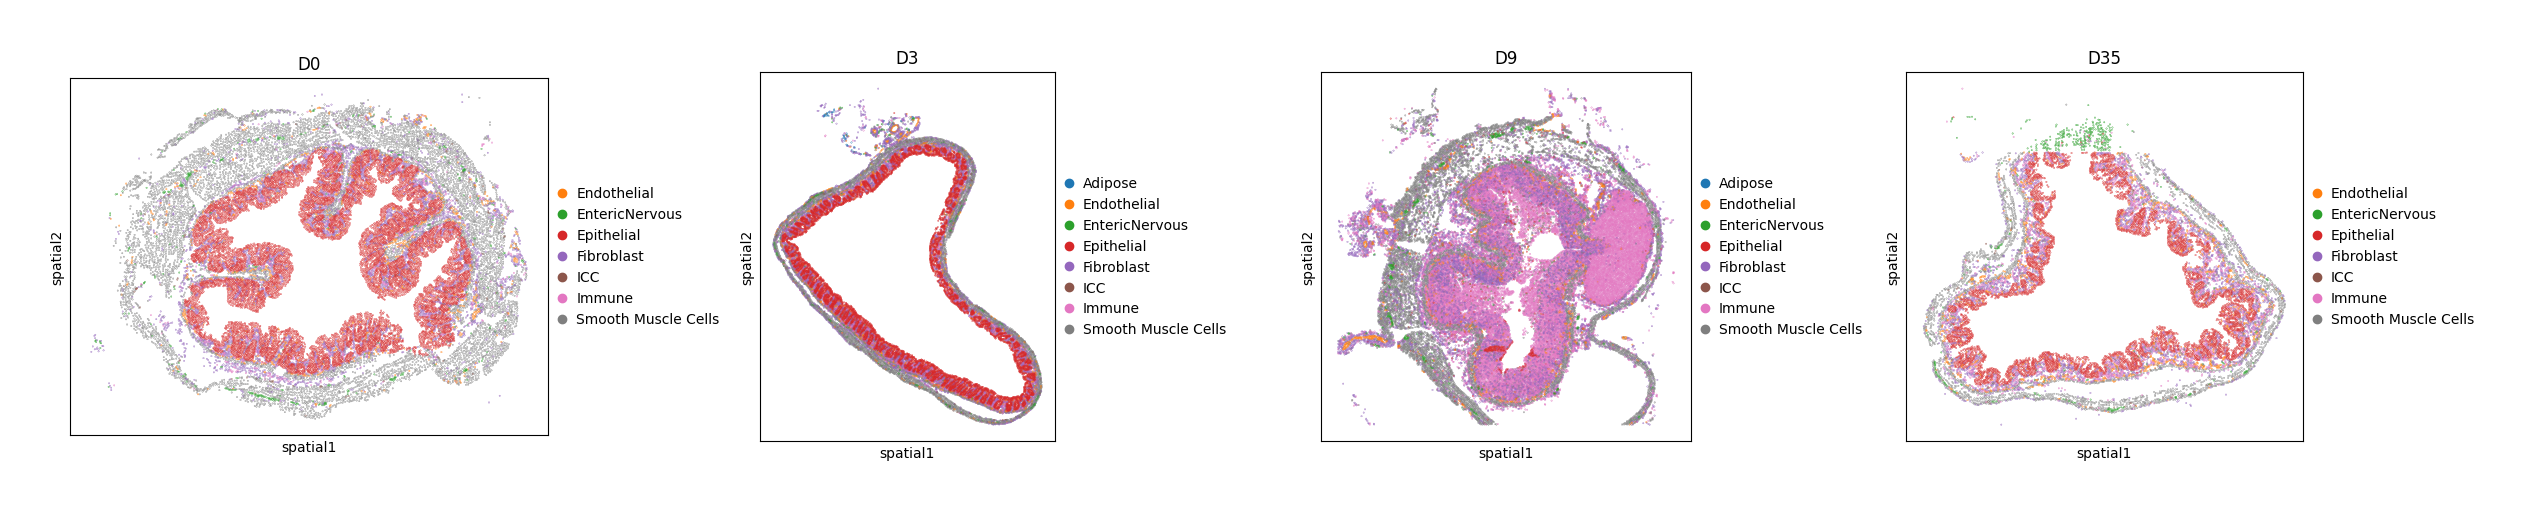

In [2]:
adata = sc.read_h5ad("/nfs/research/saezrodriguez/data/ERC_CartoHostBug/MERFISH/full_adata.h5ad")
adata = adata[adata.obs["Sample_type"] != "DSS21"].copy()

# Take out "DSS" and make Healthy 0 from Sample_type
adata.obs["time"] = adata.obs["Sample_type"].apply(lambda x: 0 if x == "Healthy" else x.replace("DSS", ""))
adata.obs["time"] = adata.obs["time"].astype(str).astype(int)

# add obs names
adata.obs_names = adata.obs["Cell_ID"].to_list()

cats = sorted(adata.obs["TierMINA"].dropna().unique())
# Force all slices to use the same categories, even if some are absent
adata.obs["TierMINA"] = pd.Categorical(
    adata.obs["TierMINA"],
    categories=cats,
    ordered=False,
)

sq.pl.spatial_scatter(
    adata,
    library_key= "Slice_ID",
    library_id = ["062921_D0_m3a_2_slice_2", "092421_D3_m4_1_slice_3", 
                  "062921_D9_m5_1_slice_1", "072523_D35_m11_1_slice_1"],
    shape=None,
    color=[
        "Tier1"
    ],
    ncols=4,
    title = ["D0", "D3", "D9", "D35"],
)

#### Identifying contaminating markers

Given the potential contamination of markers based on wrong transcript assignment and segmentation, we are conservative on which genes to include in the multiview

In [3]:
# We extract the metadata based on our column that is the reference
# Filter adata to only include ileum
# Process adata_raw
metadata = mca.up.extract_metadata_from_obs(obs=adata.obs, groupby="Slice_ID", sort=False)

#Define order of time points
metadata["Sample_type"] = pd.Categorical(metadata["Sample_type"], categories=["Healthy", "DSS3", "DSS9", "DSS21", "DSS35"], ordered=True)

pdata = dc.pp.pseudobulk(adata, sample_col="Slice_ID", groups_col="Tier1")

contaminants_dict = mca.up.get_contaminant_genes(pdata,
                      view_group="Tier1",
                      min_count=5,
                      min_total_count=10,
                      large_n=10,
                      min_prop=0.4,
                      lfc_threshold=1.5,
                      p_threshold=0.05)

# Manipulations on pdata
pdata.obs = pdata.obs.set_index("Slice_ID", drop=False)
pdata.obs.index.name = None

In [4]:
# Make list of adatas per pseudobulk cell type
anndata_dict = mca.up.split_anndata_by_celltype(pdata=pdata, grouping="Tier1")

# Adding gene expression total counts - TODO add to upstream as a function
for _cell_type, adata_raw in anndata_dict.items():
    # Sum across observations (rows) for each gene (column)
    if hasattr(adata_raw.X, "toarray"):
        # Sparse matrix case
        total_counts = adata_raw.X.sum(axis=0).A1  # returns 1D array
    else:
        total_counts = adata_raw.X.sum(axis=0)  # numpy array

    # Add to .var
    adata_raw.var["total_counts"] = total_counts

### Molecular views

This is a classical multicellular factor analysis processing as shown in other tutorials

In [5]:
mca.up.filt.filter_anndata_by_ncells(anndata_dict, min_cells=10)
# From all the possible samples, let's ask for at least 40%
n_samples = len(metadata.index)
min_samples =  math.trunc((n_samples * 0.9))
mca.up.filter_views_by_samples(anndata_dict, min_rows=min_samples)
mca.up.filter_genes_byexpr(anndata_dict, min_count=5, min_prop=0.4)
mca.up.filter_views_by_genes(anndata_dict, min_genes_per_view=50)
mca.up.filter_samples_by_coverage(anndata_dict, threshold=0, min_prop=0.95)
mca.up.filter_views_by_samples(anndata_dict, min_rows=min_samples)
mca.up.save_raw_counts(anndata_dict, layer_name="raw_counts")
mca.up.norm_log(anndata_dict, target_sum=1e5, exclude_highly_expressed=False, max_value=None, center=True)
contaminants_dict = {ct:values for ct, values in contaminants_dict.items() if ct in anndata_dict.keys()}
mca.up.filter_genes_by_celltype(anndata_dict, contaminants_dict)
mca.up.utils.append_view_to_var(anndata_dict)

Raw counts saved in the 'raw_counts' layer for each AnnData object.
Normalization, log-transformation, and scaling complete for all AnnData objects with target_sum = 100000.0.


In [6]:
anndata_dict

{'Endothelial': AnnData object with n_obs × n_vars = 54 × 506
     obs: 'Slice_ID', 'Tier1', 'Mouse_ID', 'Technical_repeat_number', 'Sample_type', 'dataset', 'time', 'psbulk_cells', 'psbulk_counts'
     var: 'total_counts', 'mean', 'std'
     uns: 'log1p'
     layers: 'psbulk_props', None (.X), 'raw_counts',
 'EntericNervous': AnnData object with n_obs × n_vars = 53 × 479
     obs: 'Slice_ID', 'Tier1', 'Mouse_ID', 'Technical_repeat_number', 'Sample_type', 'dataset', 'time', 'psbulk_cells', 'psbulk_counts'
     var: 'total_counts', 'mean', 'std'
     uns: 'log1p'
     layers: 'psbulk_props', None (.X), 'raw_counts',
 'Epithelial': AnnData object with n_obs × n_vars = 54 × 595
     obs: 'Slice_ID', 'Tier1', 'Mouse_ID', 'Technical_repeat_number', 'Sample_type', 'dataset', 'time', 'psbulk_cells', 'psbulk_counts'
     var: 'total_counts', 'mean', 'std'
     uns: 'log1p'
     layers: 'psbulk_props', None (.X), 'raw_counts',
 'Fibroblast': AnnData object with n_obs × n_vars = 54 × 504
     ob

### Compositional view

Here in addition we calculate center-log-ratios representing a different tissue descriptor angle

In [7]:
clr_props_adata = mca.up.get_cell_props(adata, "Slice_ID", "TierMINA", metadata)
mca.up.utils.append_view_to_var({"clr_comps":clr_props_adata})
anndata_dict["clr_comps"] = clr_props_adata

### Spatial view

Finally, we calculate a descriptor of spatial organization

In [ ]:
spatial_interaction_adata = mca.up.get_nhood_enrichment_feats(
    adata,
    sample_key="Slice_ID",
    cluster_key="TierMINA",
    diagonal = True, # To consider self-interactions
    n_perms=1000,
    metadata=metadata
)

# Don't forget to add the view name to the variables for compatibility
mca.up.utils.append_view_to_var({"Spatial":spatial_interaction_adata})
anndata_dict["spatial"] = spatial_interaction_adata

### MEFISTOcell

To set up time-guided factors, we configure the `factor prior` as following a `Gaussian Process`, specifying the covariate ("time"), to model factors as smooth functions of time (here stored in .obsm). This forces latent factors, representing biological processes, to evolve gradually over time rather than independently at each time point.

In [9]:
for cell_type, ad in anndata_dict.items():
    # Add the time in .obs to .obsm as numpy.ndarray
    ad.obsm["time"] = ad.obs["time"].to_numpy().reshape(-1, 1)

**Kernel**: The `"RBF"` (Radial Basis Function) kernel is the default choice and works well for most smooth, continuous data like time-series or spatial patterns. It assumes infinitely smooth functions, which is ideal when your underlying signal changes gradually. Only switch to `"Matern"` if your data has sharp discontinuities or is inherently rough and noisy, as it offers more control over smoothness.

**Inducing points**: These reduce computational cost by approximating the GP at a subset of points. Start with `100` for typical datasets (default), or use `√N` as a quick rule of thumb (e.g., 300 for 100K samples). Increase if your model underfits or results look jagged; decrease if training is too slow. More points are needed for high-dimensional covariates or complex patterns.

WARNING	Device cuda is not available. Using default device: cpu


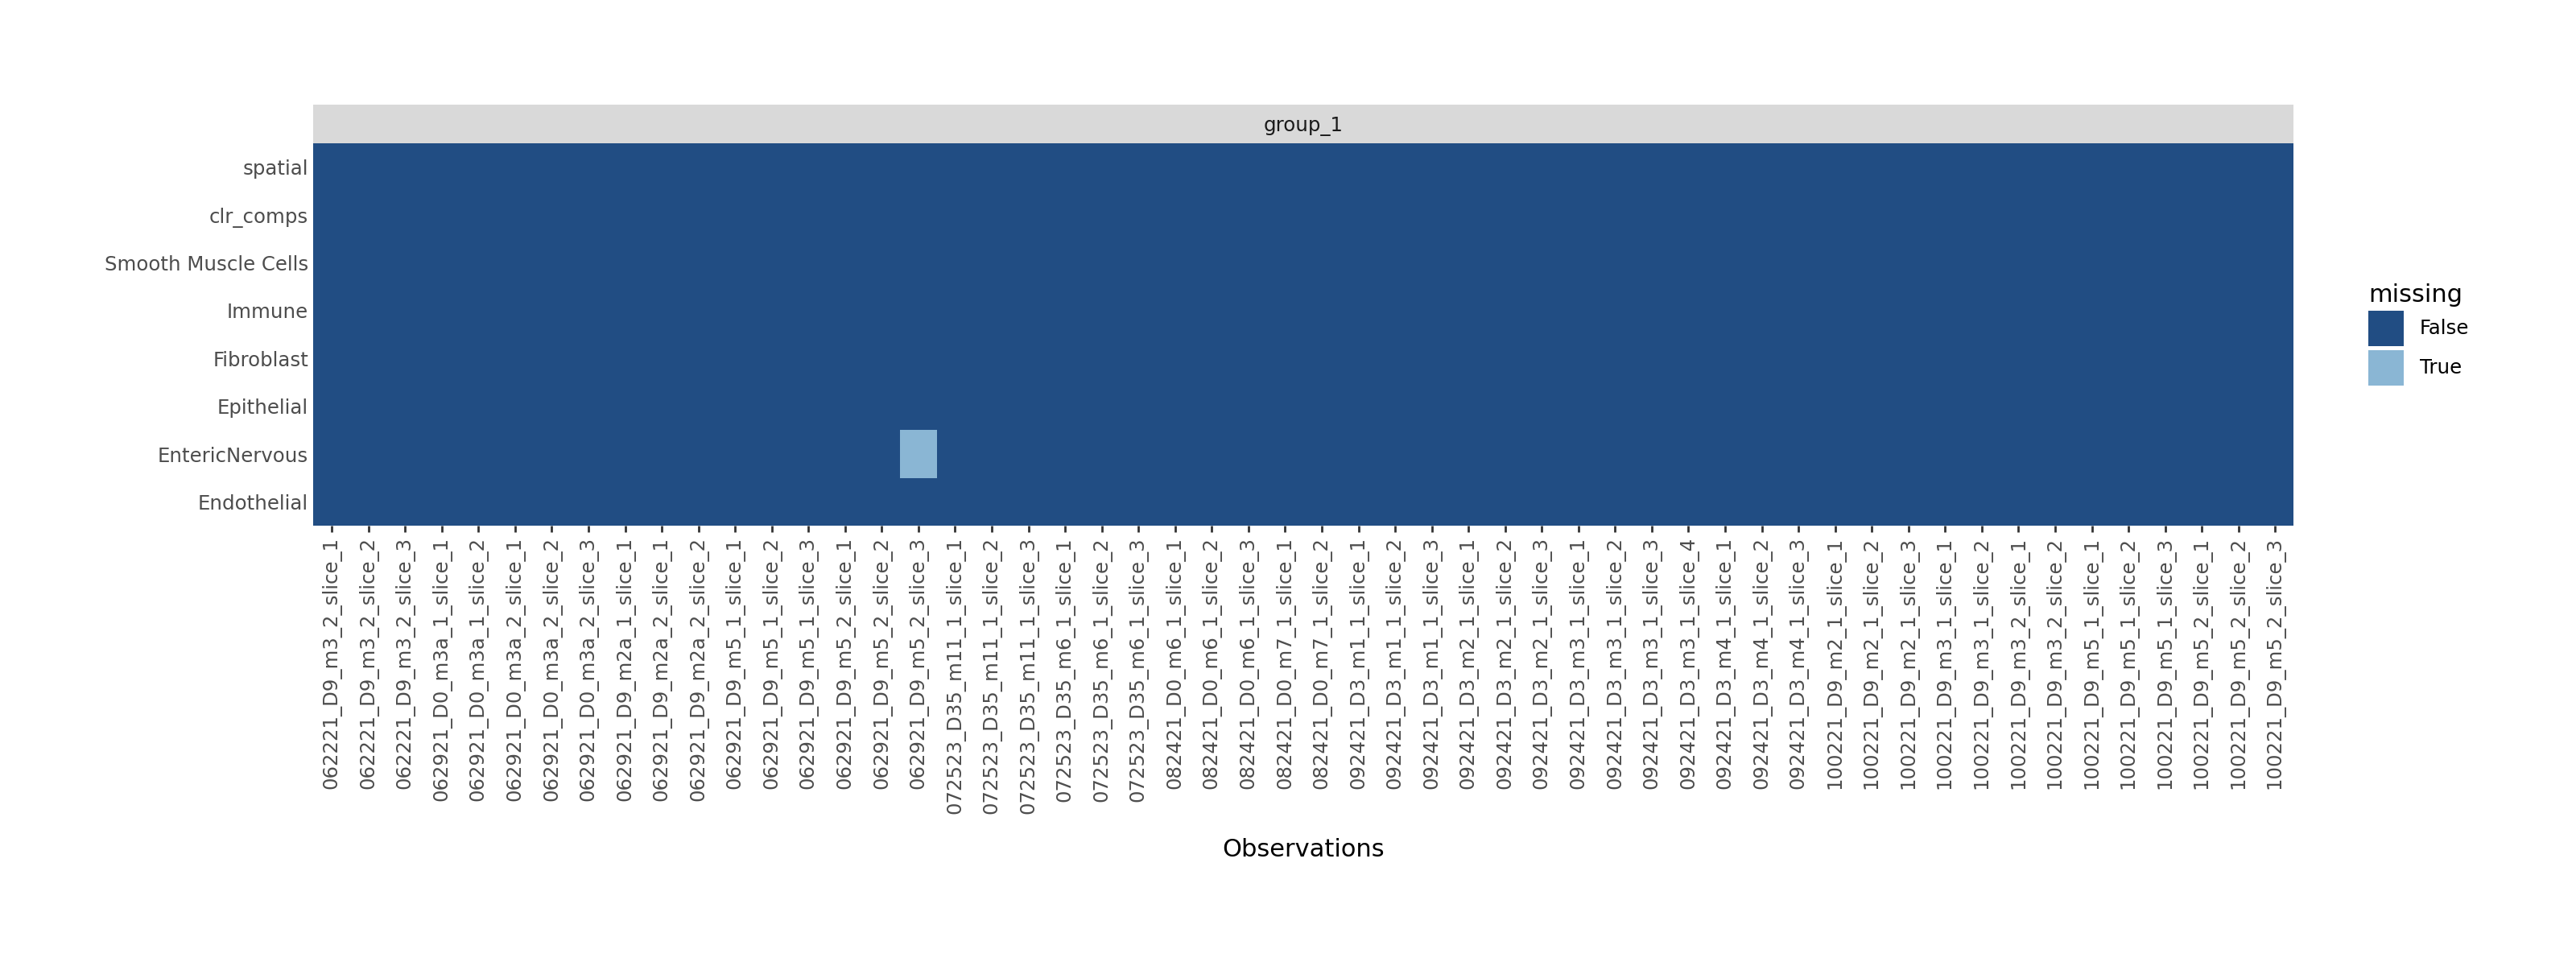

INFO	Initializing factors using 'pca' method...
  8%|▊         | 845/10000 [00:54<09:38, 15.83epoch/s, Loss=6.78e+3]

100%|██████████| 10000/10000 [10:48<00:00, 15.41epoch/s, Loss=4.81e+3] 
INFO	Saving results to mofaflex_20260903_080100.h5...


In [10]:
mdata = md.MuData(anndata_dict)

# Fitting model
model_time = mf.terms.MofaFlex(
    n_factors=10,
    weight_prior="Horseshoe",
    factor_prior=mf.priors.GaussianProcess(
        covariates_mkey="time", 
        n_inducing=100, 
        kernel="RBF"
    ),
    nonnegative_weights=False,
    nonnegative_factors=False,
    init_factors="pca"
)

model_time.fit(
    mdata,
    likelihoods=mf.likelihoods.Normal(scale_per_group=True),
    early_stopper_patience=2000,
    lr=0.001,
)

### Understanding the model

MOFA-FLEX provides already several functions to explore models with Gaussian Process priors

The model has learnt scale parameters for each factor, which give us an indication of the smoothness per factor along the covariate with values between 0 and 1. A scale of 0 means that the factor captures variation independent of time, a value close to 1 tells us that this factor varys very smoothly along time.

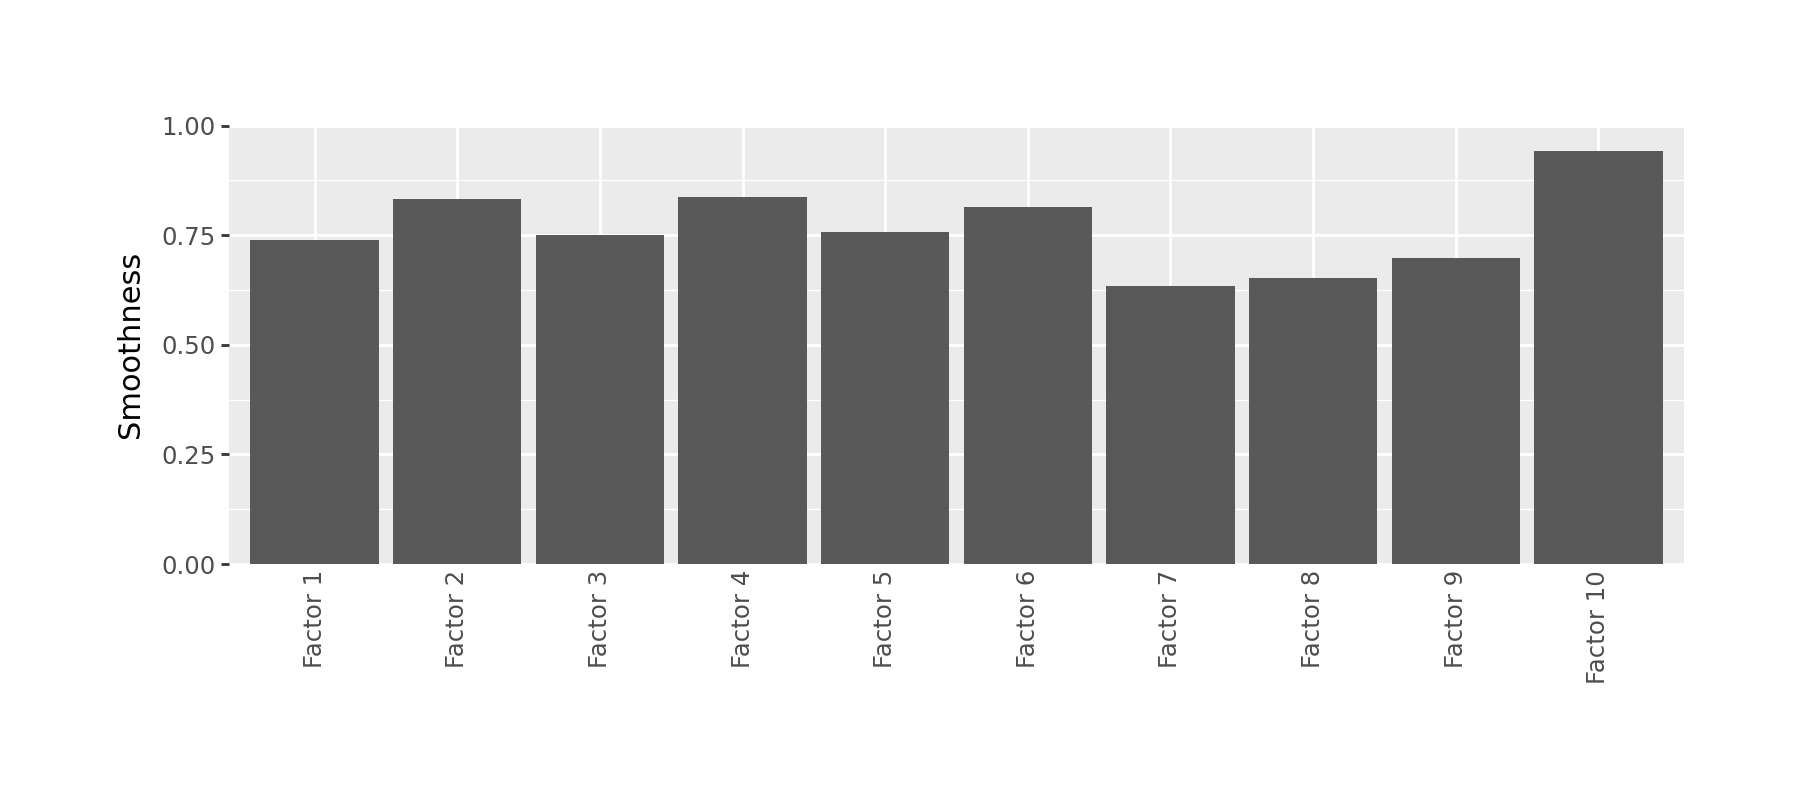

In [11]:
 mf.pl.factor_gp_smoothness(model_time, figsize=(8, 3))

In this case, all factors capture variation dependent of time. 

For each factor, one can plot the GP posterior mean for each factor as a line over time, with a 95% confidence interval band to show uncertainty. This is useful for checking if factors vary smoothly or exhibit expected temporal patterns.

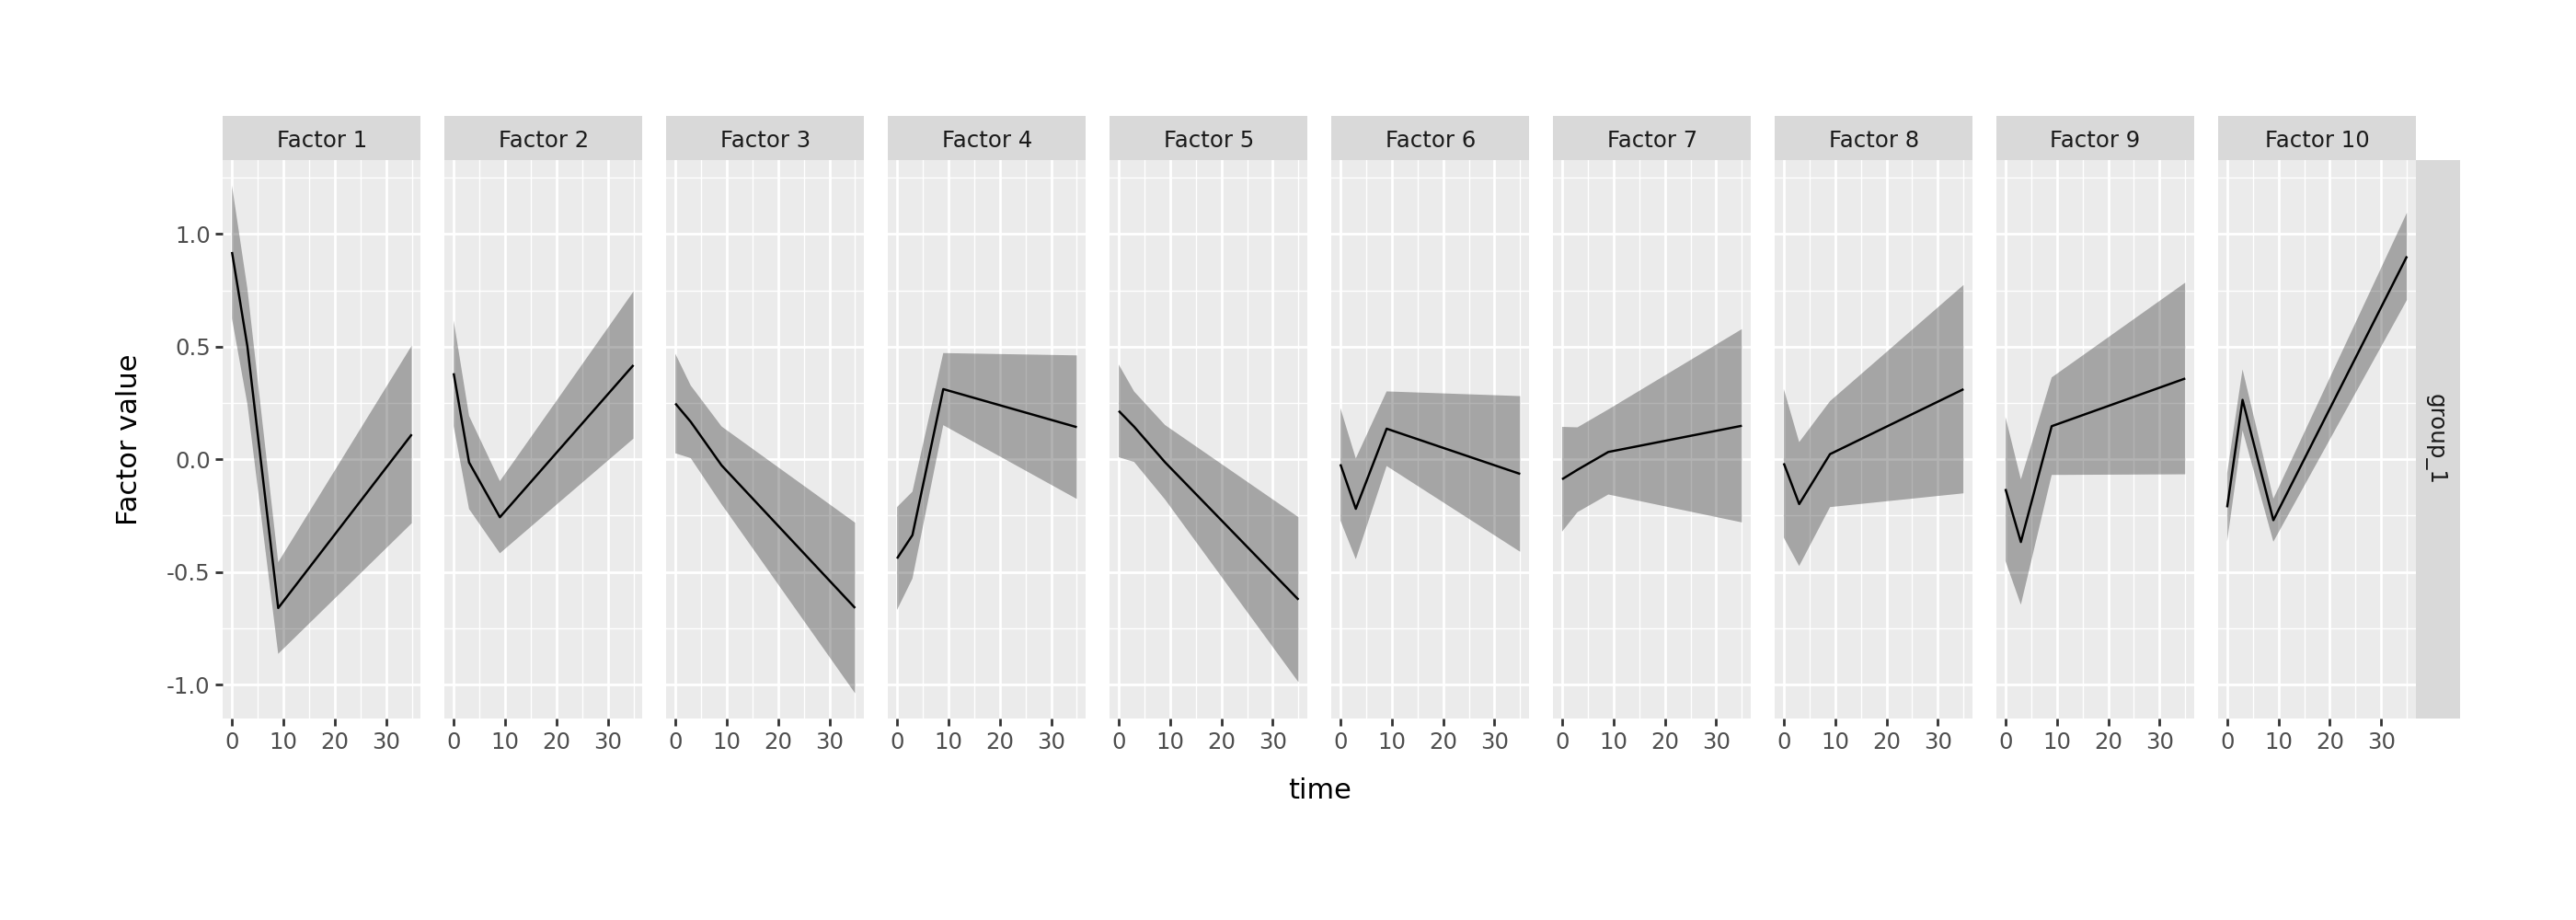

In [12]:
mf.pl.factor_gp_covariates(model_time,
                           group="facet",
                           figsize=(13, 4))

Now we can look at the explained variance of each factor now that we know they are capturing time

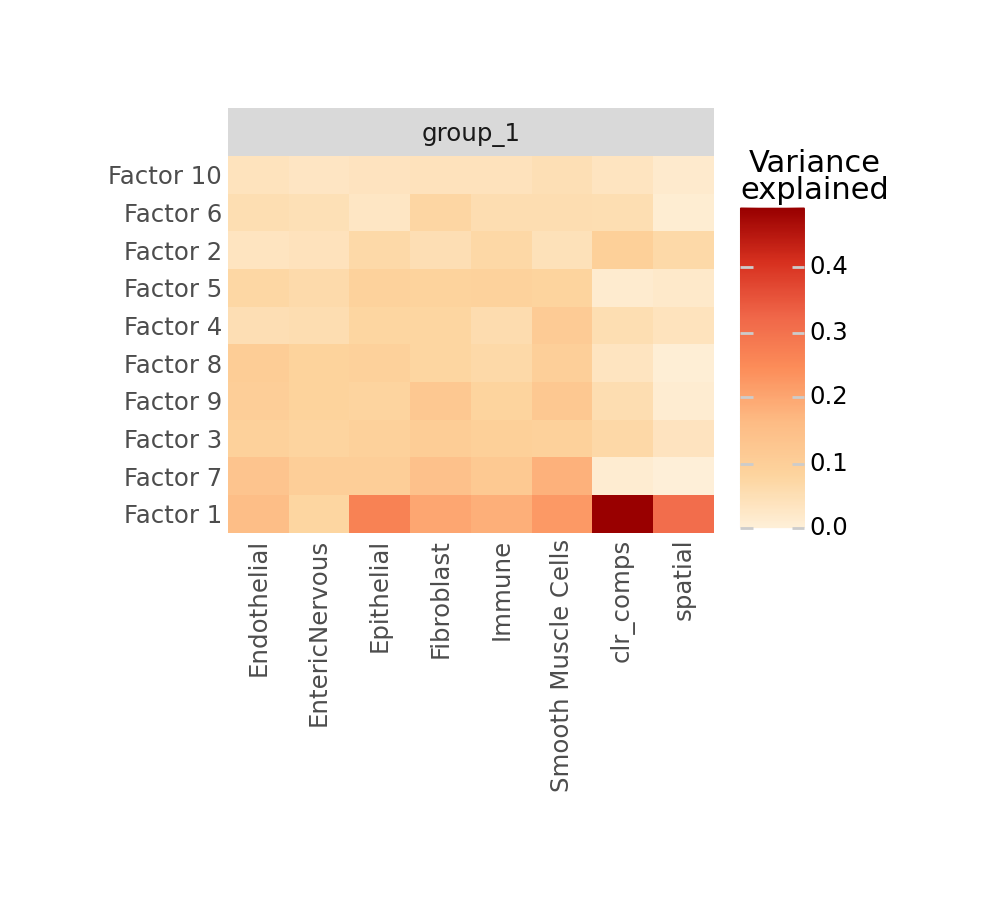

In [16]:
mf.pl.variance_explained(model_time, figsize=(4, 3.5))

Factor 1 is the factor where changes in the structure of the tissue (spatial organization and cell-state compositions) align the most with transcriptional responses in major cell-types.

Now, let's transform the model into an anndata to continue with exploratory analyses

In [17]:
amodel_full = mca.down.model_to_anndata(
    anndata_dict=anndata_dict,
    metadata=metadata,
    model=model_time,
)

amodel_full.obs["Sample_type"] = pd.Categorical(amodel_full.obs["Sample_type"], 
                                           categories = ["Healthy", "DSS3", "DSS9", "DSS35"],
                                           ordered=True)

We can focus on four different trajectories of tissue remodeling capturing peak inflammation at day 9, progressive damage and recovery, early damage, and persistent changes, respectively

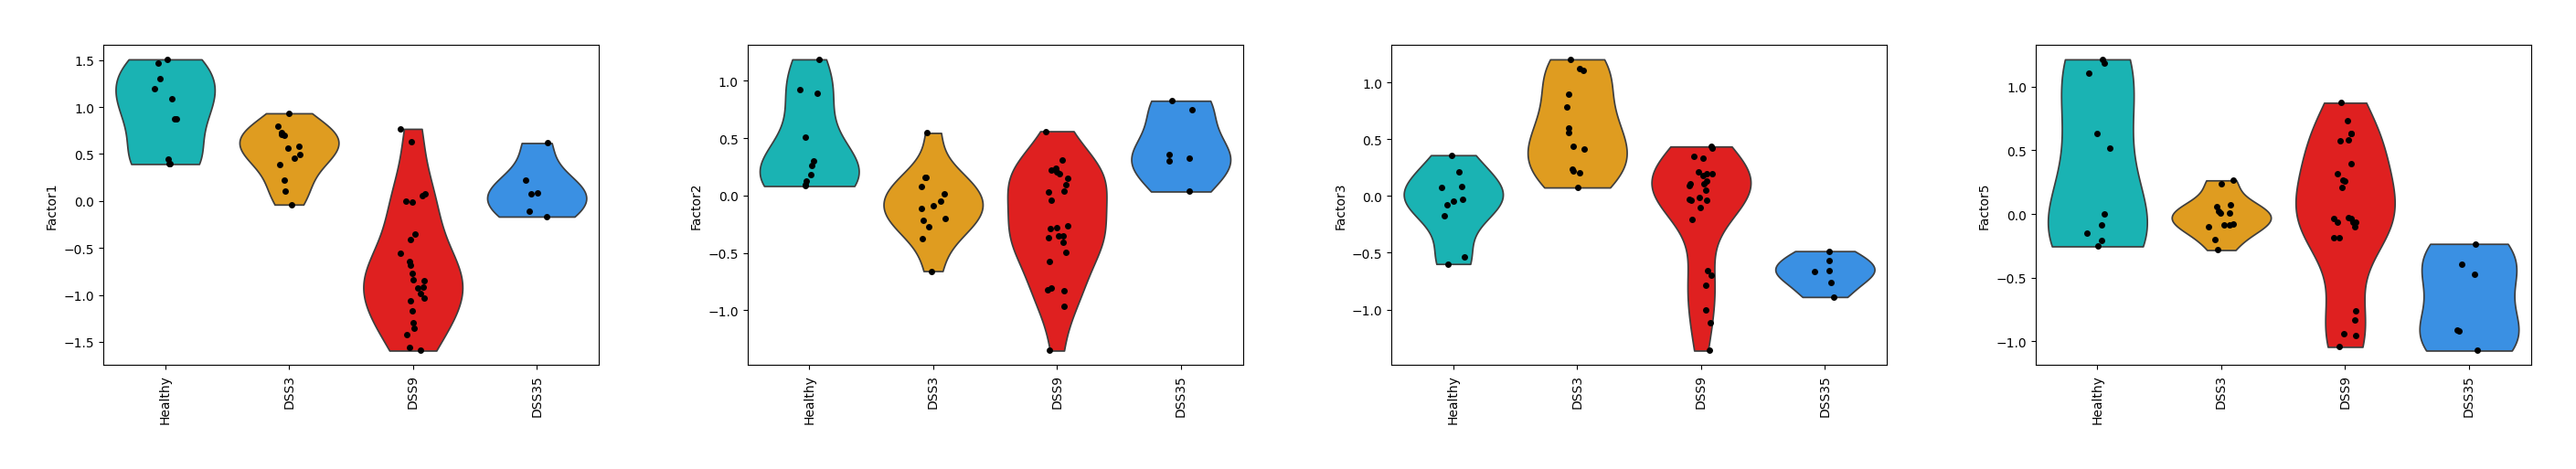

In [31]:
# Using a explicit dictionary of colors for each group
custom_palette_dict = {'Healthy': "#00cdcd", 'DSS3': 'orange', 'DSS9': 'red', 'DSS35': 'dodgerblue'}
custom_palette = ["#00cdcd", "orange", "red", "dodgerblue"]
sc.pl.violin(amodel_full,
            ["Factor1", "Factor2","Factor3", "Factor5"], 
             groupby="Sample_type", rotation=90,size = 5, 
             palette=custom_palette_dict)



We can also look at the two factors associated with the trajectories of damage and subsequent recovery expected in this dataset

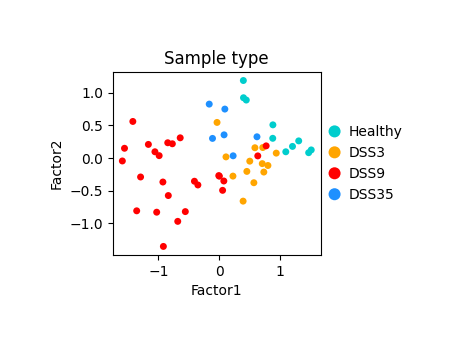

In [29]:
sc.pl.scatter(amodel_full,
              x = "Factor1",
              y = "Factor2", 
              color  = "Sample_type", 
              size =100,
              show=False,
              palette=custom_palette)

fig = plt.gcf()
fig.set_size_inches(3.5, 2.5)

ax = fig.gca()
ax.grid(False)


Similarly as in any other tutorial in mc-ASTRA, you can characterize the factors with all the downstream tools available. For a quick example, we will look at inflammatory pathways across factors

In [32]:
# Characterizing Factor Loadings
# First we need to make the gene loadings a pandas DataFrame with named columns and indexes
# Wrap as DataFrame for readability - This could be a function - users will forget to do this
wide_loadings = pd.DataFrame(amodel_full.varm["gene_loadings"], columns=amodel_full.uns['gene_loadings_columns'])
wide_loadings.index = amodel_full.var.index.to_list()

# Make a list with the different type of loadings
loadings = mca.down.split_by_view(wide_loadings.copy())
loadings = {k: v.loc[["Factor1","Factor2", "Factor3","Factor5"]] for k, v in loadings.items()}

In [33]:
gene_loadings = {
    i: loadings[i]
    for i in loadings.keys()
    if i not in ["clr_comps", "Spatial"]
}

progeny_full = dc.op.progeny(organism="mouse", top=500)

paths = ["NFkB", "JAK-STAT", "TNFa"]
progeny_full = progeny_full[progeny_full["source"].isin(paths)]

# Now you can run decoupler for each matrix of gene loadings
mcp_pws = mca.down.run_ulm_per_view(view_dict=gene_loadings, net= progeny_full)

Running ULM for view: Endothelial
Running ULM for view: EntericNervous
Running ULM for view: Epithelial
Running ULM for view: Fibroblast
Running ULM for view: Immune
Running ULM for view: Smooth Muscle Cells


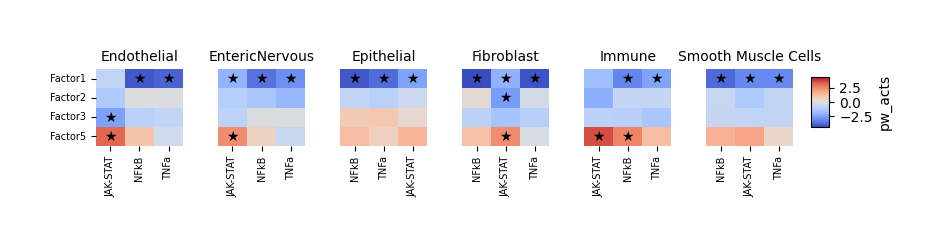

In [37]:
mca.pl.plot_mcell_funcomics(mcp_pws, 
                     p_threshold=0.05,
                     top_n=15,
                     use_var=True,
                     figsize=(9, 1), 
                     center = 0)

As expected Factor 1 captures the activation of inflammatory pathway activities that peak at day 9 and resolve by day 35.

Within mc-ASTRA we also provide plotting functions to look at how specific features behave through time. For example cell-state compositions

(<Figure size 800x400 with 2 Axes>,
 array([<Axes: title={'center': 'IAE'}>,
        <Axes: title={'center': 'Monocyte'}>], dtype=object))

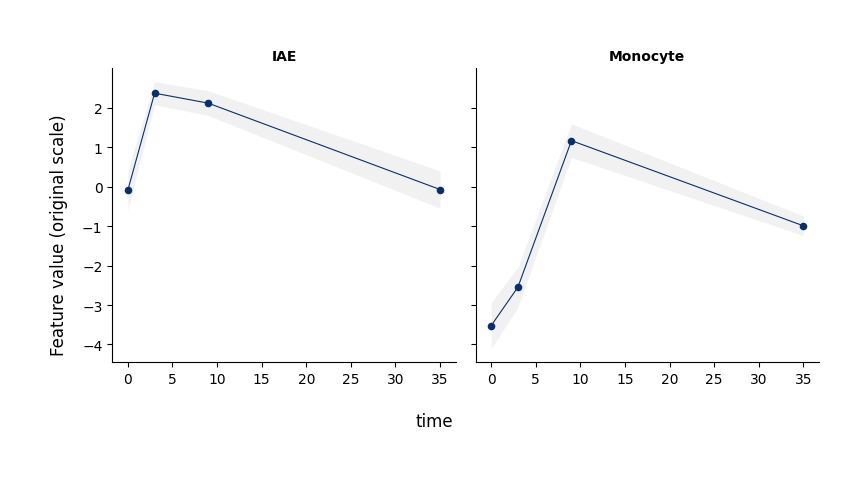

In [43]:
mca.pl.plot_feats_through_cov(adata = amodel_full, features = ["IAE", "Monocyte"], view = "clr_comps", covariate = "time")

## Summary

This notebook shows how mc-ASTRA can be used to derive spatiotemporal multicellular programs that associate changes in gene expression with tissue structural changes including changes in cell-state composition and spatial organization. We invite you to read mc-ASTRA's manuscript to complement this tutorial and see other downstream analysis possible with this type of models